In [2]:
# Import packages
### YOUR CODE HERE ### 

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

In [3]:
import pandas as pd
metadata = pd.read_csv('metadata.csv')
print(metadata.head())
print(metadata['species'].value_counts())

   image_id            identity  \
0         0  LynxID2025_lynx_37   
1         1  LynxID2025_lynx_37   
2         2  LynxID2025_lynx_49   
3         3                 NaN   
4         4  LynxID2025_lynx_13   

                                                path date orientation species  \
0  images/LynxID2025/database/000f9ee1aad063a4485...  NaN       right    lynx   
1  images/LynxID2025/database/0020edb6689e9f78462...  NaN        left    lynx   
2  images/LynxID2025/database/003152e4145b5b69400...  NaN        left    lynx   
3  images/LynxID2025/query/003b89301c7b9f6d18f722...  NaN        back    lynx   
4  images/LynxID2025/database/003c3f82011e9c3f849...  NaN       right    lynx   

      split     dataset  
0  database  LynxID2025  
1  database  LynxID2025  
2  database  LynxID2025  
3     query  LynxID2025  
4  database  LynxID2025  
species
loggerhead turtle    9229
lynx                 3903
salamander            689
Name: count, dtype: int64


In [4]:
import pandas as pd
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']
query = metadata[metadata['split'] == 'query']
print("Database size:", len(database))
print("Query size:", len(query))

Database size: 13074
Query size: 2135


In [5]:
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    unique_ids = database[database['species'] == species]['identity'].nunique()
    print(f"{species}: {unique_ids} individuos únicos")

loggerhead turtle: 438 individuos únicos
lynx: 77 individuos únicos
salamander: 0 individuos únicos


loggerhead turtle - Identity: SeaTurtleID2022_t001


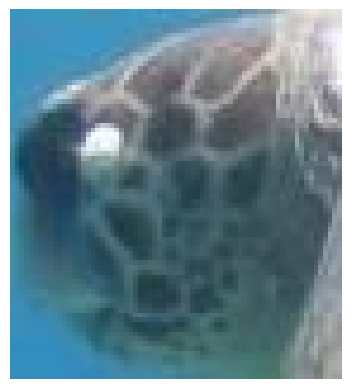

lynx - Identity: LynxID2025_lynx_37


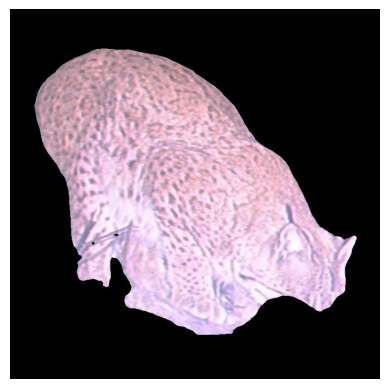

No hay datos en 'database' para salamander en esta muestra.


In [6]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Asumiendo que ya cargaste metadata.csv y separaste database
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']

# Función para mostrar imágenes
def show_image(path):
    img = Image.open(path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Iterar sobre las especies
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    species_data = database[database['species'] == species]
    if not species_data.empty:  # Verifica si hay datos para la especie
        sample = species_data.iloc[0]
        print(f"{species} - Identity: {sample['identity']}")
        show_image(sample['path'])
    else:
        print(f"No hay datos en 'database' para {species} en esta muestra.")

In [7]:
import pandas as pd

# Cargar el archivo metadata.csv
metadata = pd.read_csv('metadata.csv')

# Separar en database y query
database = metadata[metadata['split'] == 'database']
query = metadata[metadata['split'] == 'query']

# Función para analizar nulos y duplicados
def check_data_quality(df, name):
    print(f"\n--- Análisis de {name} ---")
    # Tamaño del dataset
    print(f"Tamaño: {len(df)} filas")
    
    # Valores nulos por columna
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    
    # Porcentaje de nulos
    print("\nPorcentaje de valores nulos:")
    print((df.isnull().sum() / len(df)) * 100)
    
    # Filas duplicadas (considerando todas las columnas)
    duplicated_rows = df.duplicated().sum()
    print(f"\nFilas duplicadas: {duplicated_rows}")
    
    # Duplicados en columnas clave (e.g., image_id, path)
    print(f"Duplicados en 'image_id': {df['image_id'].duplicated().sum()}")
    print(f"Duplicados en 'path': {df['path'].duplicated().sum()}")

# Analizar los tres conjuntos
check_data_quality(metadata, "Metadata completo")
check_data_quality(database, "Database")
check_data_quality(query, "Query")


--- Análisis de Metadata completo ---
Tamaño: 15209 filas

Valores nulos por columna:
image_id          0
identity       2135
path              0
date           3907
orientation     703
species        1388
split             0
dataset           0
dtype: int64

Porcentaje de valores nulos:
image_id        0.000000
identity       14.037741
path            0.000000
date           25.688737
orientation     4.622263
species         9.126175
split           0.000000
dataset         0.000000
dtype: float64

Filas duplicadas: 0
Duplicados en 'image_id': 0
Duplicados en 'path': 0

--- Análisis de Database ---
Tamaño: 13074 filas

Valores nulos por columna:
image_id          0
identity          0
path              0
date           2961
orientation     203
species        1388
split             0
dataset           0
dtype: int64

Porcentaje de valores nulos:
image_id        0.000000
identity        0.000000
path            0.000000
date           22.648004
orientation     1.552700
species        1

In [8]:
database_clean = database.dropna(subset=['species'])
print(f"Tamaño de database limpio: {len(database_clean)}")

Tamaño de database limpio: 11686


In [9]:
import pandas as pd

# Asumiendo que ya tienes database_clean
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']
database_clean = database.dropna(subset=['species'])

print("Distribución de especies en database limpio:")
print(database_clean['species'].value_counts())
print("\nNúmero de individuos únicos por especie:")
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    unique_ids = database_clean[database_clean['species'] == species]['identity'].nunique()
    print(f"{species}: {unique_ids} individuos únicos")

Distribución de especies en database limpio:
species
loggerhead turtle    8729
lynx                 2957
Name: count, dtype: int64

Número de individuos únicos por especie:
loggerhead turtle: 438 individuos únicos
lynx: 77 individuos únicos
salamander: 0 individuos únicos


In [10]:
import pandas as pd

metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']

print("Distribución de especies en database original:")
print(database['species'].value_counts(dropna=False))

print("\nNúmero de individuos únicos por especie en database original:")
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    unique_ids = database[database['species'] == species]['identity'].nunique()
    print(f"{species}: {unique_ids} individuos únicos")

Distribución de especies en database original:
species
loggerhead turtle    8729
lynx                 2957
NaN                  1388
Name: count, dtype: int64

Número de individuos únicos por especie en database original:
loggerhead turtle: 438 individuos únicos
lynx: 77 individuos únicos
salamander: 0 individuos únicos


In [11]:
import pandas as pd

# Cargar metadata
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']
query = metadata[metadata['split'] == 'query']

# Función para inferir especie desde el path
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

# Rellenar especies nulas en database
database_clean = database.copy()  # Copia para no modificar el original
mask = database_clean['species'].isnull()  # Filas con species nulo
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Verificar resultados
print("Distribución de especies en database limpio (con inferencia):")
print(database_clean['species'].value_counts(dropna=False))

print("\nNúmero de individuos únicos por especie:")
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    unique_ids = database_clean[database_clean['species'] == species]['identity'].nunique()
    print(f"{species}: {unique_ids} individuos únicos")

print(f"\nTamaño de database limpio: {len(database_clean)}")

Distribución de especies en database limpio (con inferencia):
species
loggerhead turtle    8729
lynx                 2957
salamander           1388
Name: count, dtype: int64

Número de individuos únicos por especie:
loggerhead turtle: 438 individuos únicos
lynx: 77 individuos únicos
salamander: 587 individuos únicos

Tamaño de database limpio: 13074


In [12]:
import pandas as pd

# Cargar metadata y preparar database_clean
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']
query = metadata[metadata['split'] == 'query']

# Inferir especies
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

database_clean = database.copy()
mask = database_clean['species'].isnull()
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Función para analizar nulos y duplicados
def check_data_quality(df, name):
    print(f"\n--- Análisis de {name} ---")
    print(f"Tamaño: {len(df)} filas")
    
    # Valores nulos por columna
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    
    # Porcentaje de valores nulos
    print("\nPorcentaje de valores nulos:")
    print((df.isnull().sum() / len(df)) * 100)
    
    # Filas duplicadas
    print(f"\nFilas duplicadas: {df.duplicated().sum()}")
    
    # Duplicados en columnas clave
    print(f"Duplicados en 'image_id': {df['image_id'].duplicated().sum()}")
    print(f"Duplicados en 'path': {df['path'].duplicated().sum()}")

# Analizar database_clean y query
check_data_quality(database_clean, "Database limpio (con inferencia)")
check_data_quality(query, "Query")


--- Análisis de Database limpio (con inferencia) ---
Tamaño: 13074 filas

Valores nulos por columna:
image_id          0
identity          0
path              0
date           2961
orientation     203
species           0
split             0
dataset           0
dtype: int64

Porcentaje de valores nulos:
image_id        0.000000
identity        0.000000
path            0.000000
date           22.648004
orientation     1.552700
species         0.000000
split           0.000000
dataset         0.000000
dtype: float64

Filas duplicadas: 0
Duplicados en 'image_id': 0
Duplicados en 'path': 0

--- Análisis de Query ---
Tamaño: 2135 filas

Valores nulos por columna:
image_id          0
identity       2135
path              0
date            946
orientation     500
species           0
split             0
dataset           0
dtype: int64

Porcentaje de valores nulos:
image_id         0.000000
identity       100.000000
path             0.000000
date            44.309133
orientation     23.419204


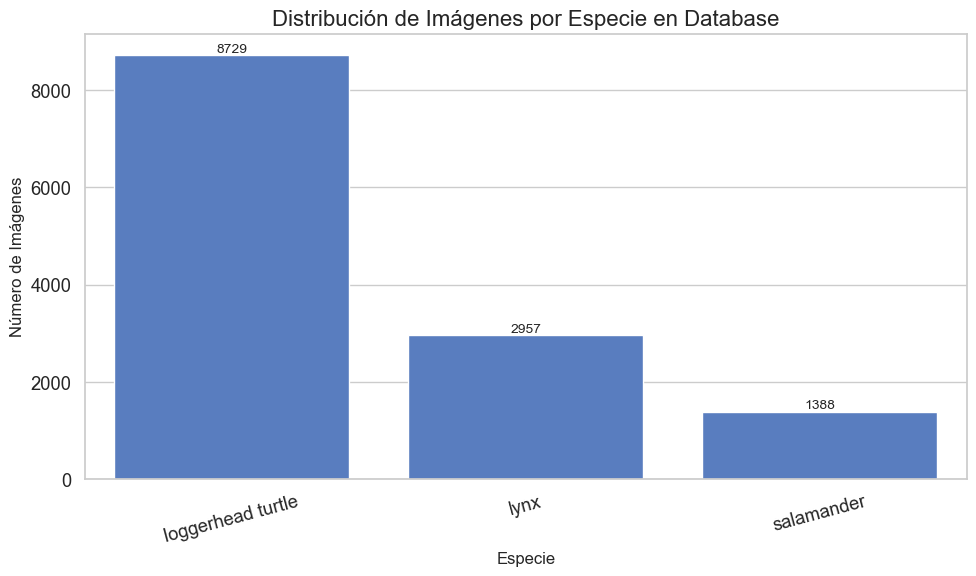

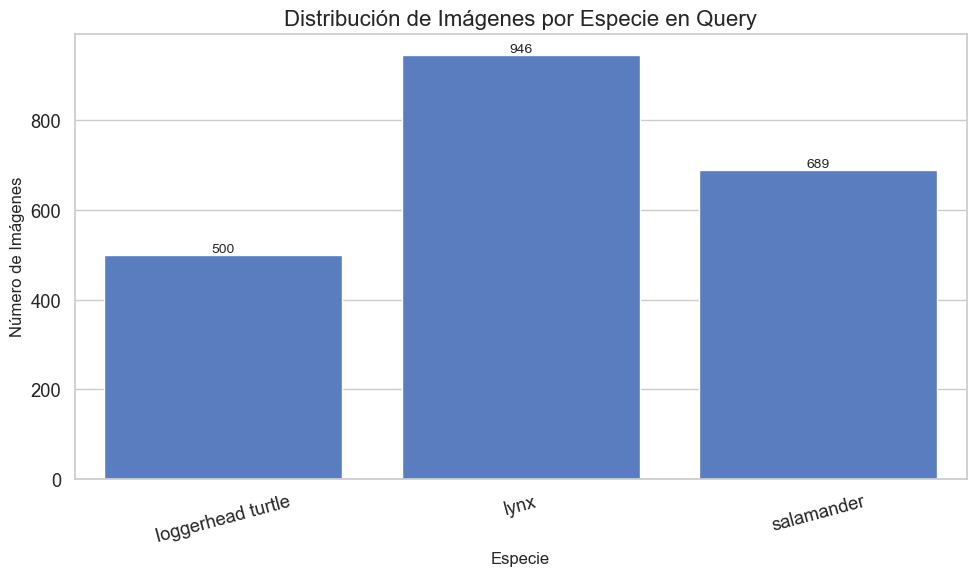

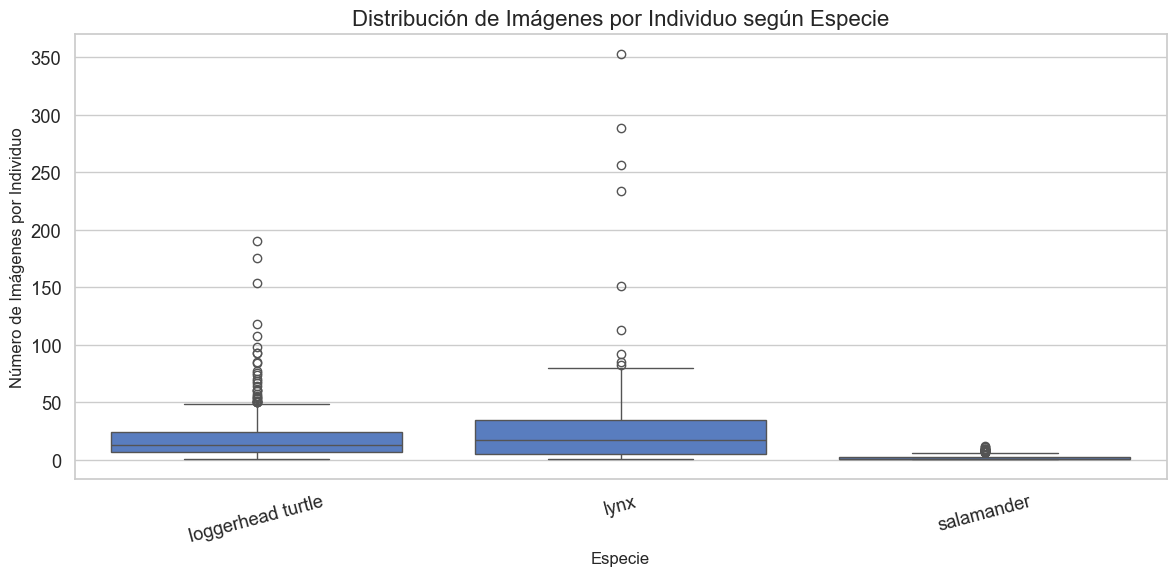

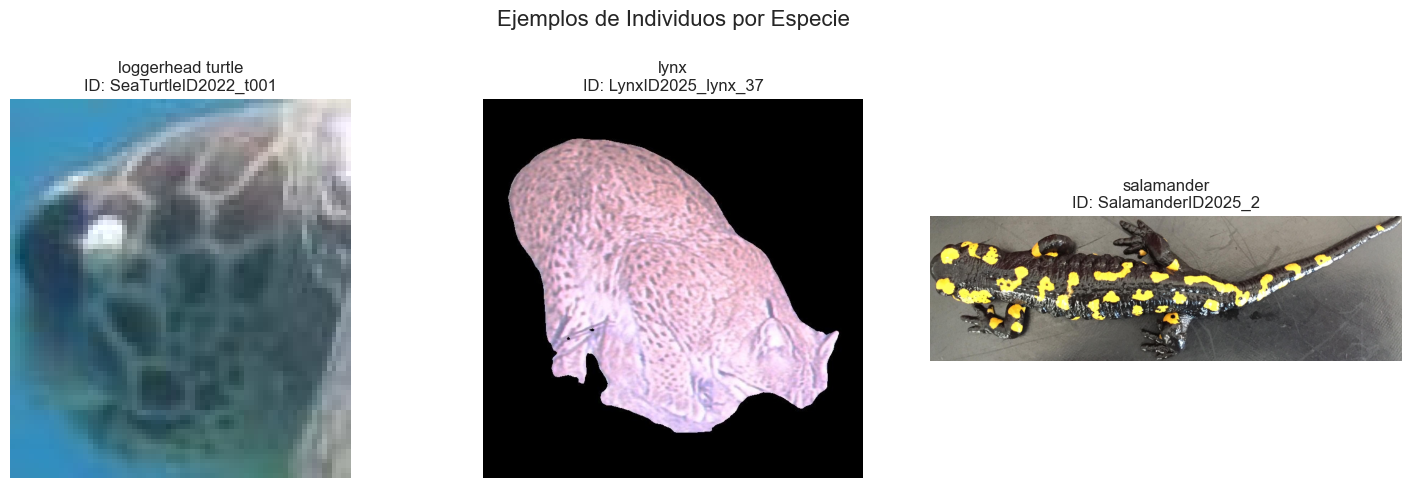

<Figure size 1200x600 with 0 Axes>

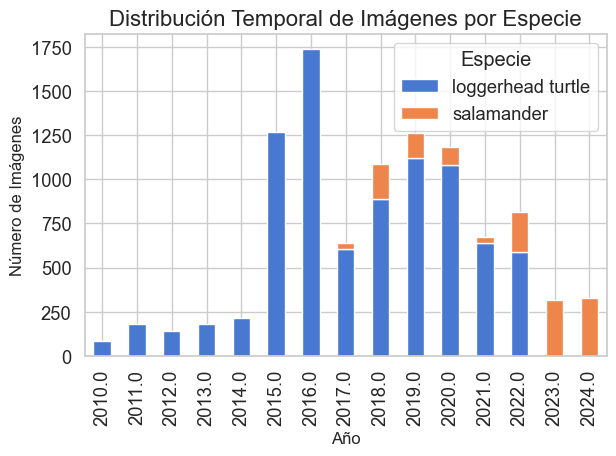

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Cargar datos
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']
query = metadata[metadata['split'] == 'query']

# Inferir especies en database
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

database_clean = database.copy()
mask = database_clean['species'].isnull()
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Configurar estilo profesional
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# 1. Distribución de imágenes por especie
plt.figure(figsize=(10, 6))
sns.countplot(data=database_clean, x='species', order=['loggerhead turtle', 'lynx', 'salamander'])
plt.title('Distribución de Imágenes por Especie en Database', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Número de Imágenes', fontsize=12)
plt.xticks(rotation=15)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Comparar con query
plt.figure(figsize=(10, 6))
sns.countplot(data=query, x='species', order=['loggerhead turtle', 'lynx', 'salamander'])
plt.title('Distribución de Imágenes por Especie en Query', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Número de Imágenes', fontsize=12)
plt.xticks(rotation=15)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# 2. Número de imágenes por individuo por especie (Boxplot)
plt.figure(figsize=(12, 6))
images_per_individual = database_clean.groupby(['species', 'identity']).size().reset_index(name='count')
sns.boxplot(data=images_per_individual, x='species', y='count', order=['loggerhead turtle', 'lynx', 'salamander'])
plt.title('Distribución de Imágenes por Individuo según Especie', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Número de Imágenes por Individuo', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 3. Ejemplos visuales de individuos
plt.figure(figsize=(15, 5))
for i, species in enumerate(['loggerhead turtle', 'lynx', 'salamander']):
    species_data = database_clean[database_clean['species'] == species]
    if not species_data.empty:
        sample = species_data.iloc[0]
        img = Image.open(sample['path'])
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"{species}\nID: {sample['identity']}", fontsize=12)
        plt.axis('off')
plt.suptitle('Ejemplos de Individuos por Especie', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Distribución temporal (si hay datos de date)
if 'date' in database_clean.columns:
    database_clean['date'] = pd.to_datetime(database_clean['date'], errors='coerce')
    plt.figure(figsize=(12, 6))
    database_clean.groupby([database_clean['date'].dt.year, 'species']).size().unstack().plot(kind='bar', stacked=True)
    plt.title('Distribución Temporal de Imágenes por Especie', fontsize=16)
    plt.xlabel('Año', fontsize=12)
    plt.ylabel('Número de Imágenes', fontsize=12)
    plt.legend(title='Especie')
    plt.tight_layout()
    plt.show()
else:
    print("No hay columna 'date' disponible para análisis temporal.")


--- Análisis de outliers para loggerhead turtle ---
Total de individuos: 438
Media de imágenes por individuo: 19.93
Desviación estándar: 21.83
Rango: 1 - 190
Outliers según Z-score (±3): 8
Valores: [118 176  98 190 154  93 108  93]
Outliers según IQR: 31
Valores: [ 56  51  60  64  76 118  61  53  50  57  50  70  54  55  84  61 176  77
  51  67  85  98 190  50  50  74 154  93 108  69  93]

--- Análisis de outliers para lynx ---
Total de individuos: 77
Media de imágenes por individuo: 38.40
Desviación estándar: 65.48
Rango: 1 - 353
Outliers según Z-score (±3): 3
Valores: [256 353 289]
Outliers según IQR: 9
Valores: [151 113 256 234  83 353 289  92  85]

--- Análisis de outliers para salamander ---
Total de individuos: 587
Media de imágenes por individuo: 2.36
Desviación estándar: 2.05
Rango: 1 - 12
Outliers según Z-score (±3): 13
Valores: [10  9 12  9 10  9 10  9 11  9 10 11  9]
Outliers según IQR: 35
Valores: [10  9  8  7 12  9  8  8  7  7  8 10  9  7  7  7  7  7  8  7  7 10  8  9
  7 

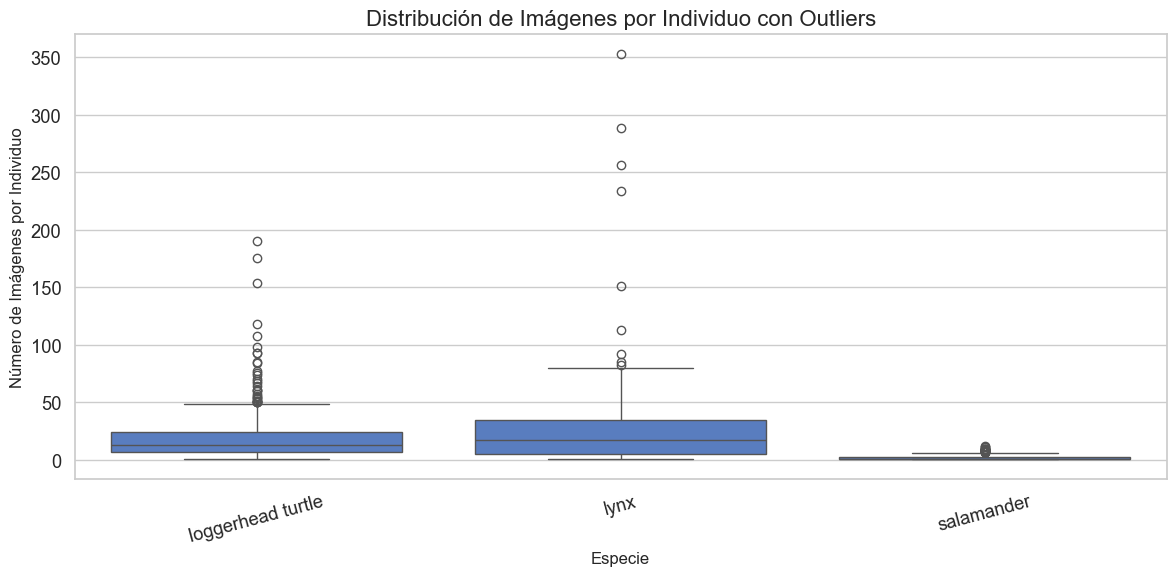

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']

# Inferir especies
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

database_clean = database.copy()
mask = database_clean['species'].isnull()
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Calcular número de imágenes por individuo
images_per_individual = database_clean.groupby(['species', 'identity']).size().reset_index(name='count')

# Funciones para detectar outliers
def detect_outliers_zscore(data, threshold=3):
    z_scores = np.abs((data - data.mean()) / data.std())
    return data[z_scores > threshold]

def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data < lower_bound) | (data > upper_bound)]

# Análisis por especie
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    species_data = images_per_individual[images_per_individual['species'] == species]['count']
    
    print(f"\n--- Análisis de outliers para {species} ---")
    print(f"Total de individuos: {len(species_data)}")
    print(f"Media de imágenes por individuo: {species_data.mean():.2f}")
    print(f"Desviación estándar: {species_data.std():.2f}")
    print(f"Rango: {species_data.min()} - {species_data.max()}")
    
    # Z-score
    outliers_zscore = detect_outliers_zscore(species_data)
    print(f"Outliers según Z-score (±3): {len(outliers_zscore)}")
    if not outliers_zscore.empty:
        print(f"Valores: {outliers_zscore.values}")
    
    # IQR
    outliers_iqr = detect_outliers_iqr(species_data)
    print(f"Outliers según IQR: {len(outliers_iqr)}")
    if not outliers_iqr.empty:
        print(f"Valores: {outliers_iqr.values}")

# Visualización con boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=images_per_individual, x='species', y='count', order=['loggerhead turtle', 'lynx', 'salamander'])
plt.title('Distribución de Imágenes por Individuo con Outliers', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Número de Imágenes por Individuo', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Tortuga con más imágenes: SeaTurtleID2022_t243


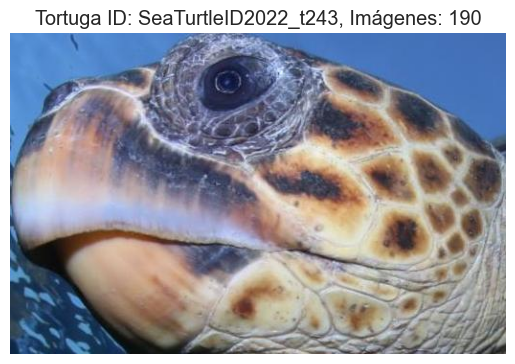

In [15]:
outlier_turtle = database_clean[database_clean['species'] == 'loggerhead turtle'].groupby('identity').size().idxmax()
print(f"Tortuga con más imágenes: {outlier_turtle}")
sample = database_clean[database_clean['identity'] == outlier_turtle].iloc[0]
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(sample['path'])
plt.imshow(img)
plt.title(f"Tortuga ID: {outlier_turtle}, Imágenes: 190")
plt.axis('off')
plt.show()

Número de imágenes para SeaTurtleID2022_t243: 190


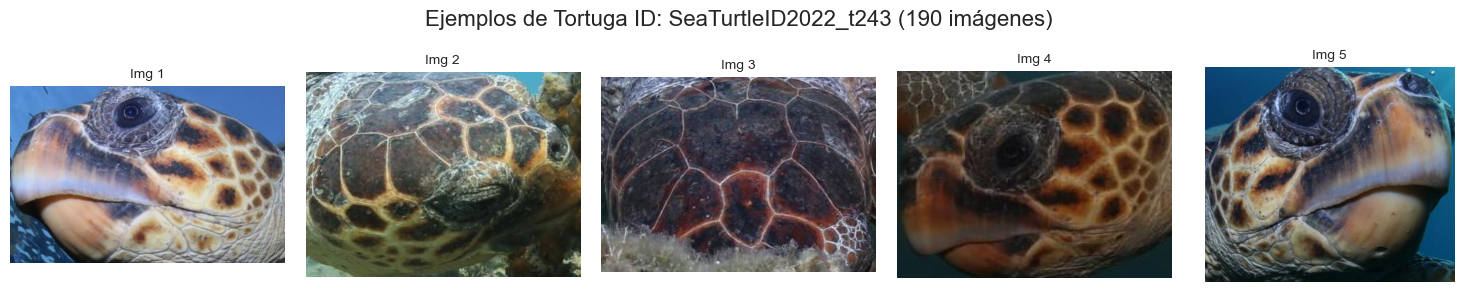

In [16]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Cargar datos
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']

# Inferir especies
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

database_clean = database.copy()
mask = database_clean['species'].isnull()
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Filtrar datos de la tortuga con más imágenes
turtle_id = 'SeaTurtleID2022_t243'
turtle_data = database_clean[database_clean['identity'] == turtle_id]
print(f"Número de imágenes para {turtle_id}: {len(turtle_data)}")

# Visualizar algunas imágenes (e.g., las primeras 5)
plt.figure(figsize=(15, 3))
for i, (_, row) in enumerate(turtle_data.iloc[:5].iterrows()):
    img = Image.open(row['path'])
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Img {i+1}", fontsize=10)
    plt.axis('off')
plt.suptitle(f"Ejemplos de Tortuga ID: {turtle_id} (190 imágenes)", fontsize=16)
plt.tight_layout()
plt.show()

Número de imágenes para SeaTurtleID2022_t243: 190


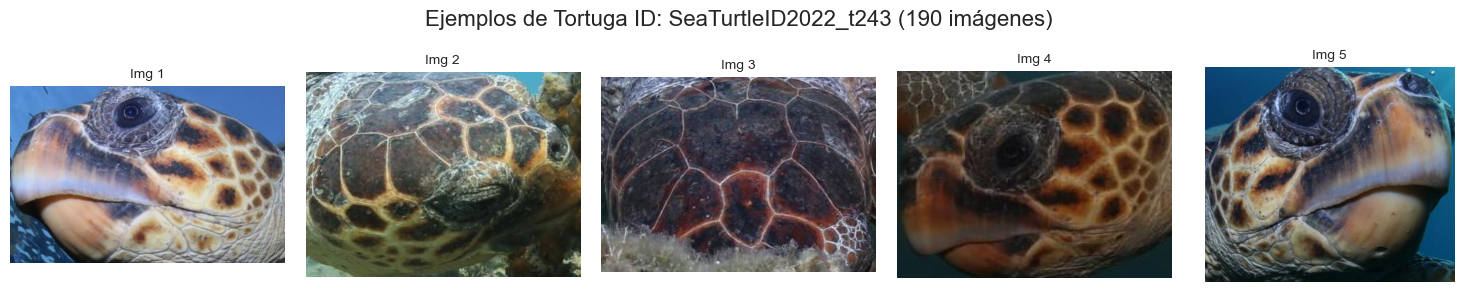

In [17]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Cargar datos
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']

# Inferir especies
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

database_clean = database.copy()
mask = database_clean['species'].isnull()
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Filtrar datos de la tortuga con más imágenes
turtle_id = 'SeaTurtleID2022_t243'
turtle_data = database_clean[database_clean['identity'] == turtle_id]
print(f"Número de imágenes para {turtle_id}: {len(turtle_data)}")

# Visualizar las primeras 5 imágenes
plt.figure(figsize=(15, 3))
for i, (_, row) in enumerate(turtle_data.iloc[:5].iterrows()):
    img = Image.open(row['path'])
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Img {i+1}", fontsize=10)
    plt.axis('off')
plt.suptitle(f"Ejemplos de Tortuga ID: {turtle_id} (190 imágenes)", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
max_images = 50
database_balanced = database_clean.groupby('identity').apply(lambda x: x.sample(n=min(len(x), max_images))).reset_index(drop=True)
print(f"Tamaño de database balanceado: {len(database_balanced)}")

Tamaño de database balanceado: 10829


/var/folders/qx/7rcy6zx958bd4l7j7kkqq8h80000gp/T/ipykernel_18597/2840121504.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  database_balanced = database_clean.groupby('identity').apply(lambda x: x.sample(n=min(len(x), max_images))).reset_index(drop=True)


In [19]:
# Distribución tras muestreo
print("Distribución de imágenes por especie tras muestreo:")
print(database_balanced['species'].value_counts())

print("\nNúmero de imágenes por individuo tras muestreo:")
images_per_individual = database_balanced.groupby(['species', 'identity']).size().reset_index(name='count')
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    species_data = images_per_individual[images_per_individual['species'] == species]['count']
    print(f"{species}:")
    print(f"  Media: {species_data.mean():.2f}")
    print(f"  Rango: {species_data.min()} - {species_data.max()}")

Distribución de imágenes por especie tras muestreo:
species
loggerhead turtle    7824
lynx                 1617
salamander           1388
Name: count, dtype: int64

Número de imágenes por individuo tras muestreo:
loggerhead turtle:
  Media: 17.86
  Rango: 1 - 50
lynx:
  Media: 21.00
  Rango: 1 - 50
salamander:
  Media: 2.36
  Rango: 1 - 12


In [20]:
pip show torch

Name: torch
Version: 2.2.2
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3
Location: /Users/ghost/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages
Requires: filelock, fsspec, jinja2, networkx, sympy, typing-extensions
Required-by: torchvision
Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import torch
from torchvision import models, transforms
from PIL import Image

# Configuración
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Transformaciones
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Modelo
model = models.resnet50(pretrained=True).to(device)
model.eval()
model = torch.nn.Sequential(*(list(model.children())[:-1]))

def load_image(path):
    try:
        img = Image.open(path).convert('RGB')
        return transform(img)
    except Exception as e:
        print(f"Error cargando {path}: {e}")
        return None

def extract_features(path):
    img = load_image(path)
    if img is None:
        return None
    img = img.unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(img).flatten()
    return features.cpu().numpy()

# Cargar datos
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']
query = metadata[metadata['split'] == 'query']

# Inferir especies
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

database_clean = database.copy()
mask = database_clean['species'].isnull()
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Muestreo para balancear
max_images = 50
database_balanced = database_clean.groupby('identity').apply(lambda x: x.sample(n=min(len(x), max_images))).reset_index(drop=True)
print(f"Tamaño de database balanceado: {len(database_balanced)}")

# Calcular embeddings
database_embeddings = {}
database_ids = {}
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    species_data = database_balanced[database_balanced['species'] == species]
    embeddings = []
    ids = []
    print(f"Procesando {species}...")
    for _, row in species_data.iterrows():
        emb = extract_features(row['path'])
        if emb is not None:
            embeddings.append(emb)
            ids.append(row['identity'])
    database_embeddings[species] = np.array(embeddings)
    database_ids[species] = ids
    print(f"{species}: {len(embeddings)} embeddings calculados")

# Función de predicción con umbrales por especie
thresholds = {'loggerhead turtle': 60.0, 'lynx': 80.0, 'salamander': 20.0}
def predict_identity(query_path, species, thresholds=thresholds):
    query_emb = extract_features(query_path)
    if query_emb is None or species not in database_embeddings or len(database_embeddings[species]) == 0:
        return "new_individual"
    distances = np.linalg.norm(database_embeddings[species] - query_emb, axis=1)
    min_dist = distances.min()
    if min_dist < thresholds[species]:
        return database_ids[species][np.argmin(distances)]
    return "new_individual"

# Generar predicciones
predictions = []
print("Prediciendo imágenes de query...")
for i, row in query.iterrows():
    species = row['species']
    pred = predict_identity(row['path'], species)
    predictions.append([row['image_id'], pred])
    if i % 100 == 0:
        print(f"Procesadas {i} imágenes de query")

# Crear submission
submission = pd.DataFrame(predictions, columns=['image_id', 'identity'])
submission.to_csv('submission.csv', index=False)
print("\nPrimeras filas del archivo de submission:")
print(submission.head())
print(f"Archivo 'submission.csv' generado con {len(submission)} predicciones")

Usando dispositivo: cpu


/Users/ghost/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ghost/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/var/folders/qx/7rcy6zx958bd4l7j7kkqq8h80000gp/T/ipykernel_18597/4175993937.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `i

Tamaño de database balanceado: 10829
Procesando loggerhead turtle...


In [ ]:
import pandas as pd
import numpy as np
import torch
from torchvision import models, transforms
from PIL import Image

# Configuración
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Transformaciones
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Modelo
model = models.resnet50(pretrained=True).to(device)
model.eval()
model = torch.nn.Sequential(*(list(model.children())[:-1]))

# Contador de errores al cargar imágenes
load_errors = 0

def load_image(path):
    global load_errors
    try:
        img = Image.open(path).convert('RGB')
        return transform(img)
    except Exception as e:
        print(f"Error cargando {path}: {e}")
        load_errors += 1
        return None

def extract_features(path):
    img = load_image(path)
    if img is None:
        return None
    img = img.unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(img).flatten()
    return features.cpu().numpy()

# Cargar datos
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']
query = metadata[metadata['split'] == 'query']

# Inferir especies
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

database_clean = database.copy()
mask = database_clean['species'].isnull()
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Muestreo para balancear
max_images = 50
database_balanced = database_clean.groupby('identity').apply(lambda x: x.sample(n=min(len(x), max_images))).reset_index(drop=True)
print(f"Tamaño de database balanceado: {len(database_balanced)}")

# Calcular embeddings
database_embeddings = {}
database_ids = {}
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    species_data = database_balanced[database_balanced['species'] == species]
    embeddings = []
    ids = []
    print(f"Procesando {species}...")
    for _, row in species_data.iterrows():
        emb = extract_features(row['path'])
        if emb is not None:
            embeddings.append(emb)
            ids.append(row['identity'])
    database_embeddings[species] = np.array(embeddings)
    database_ids[species] = ids
    print(f"{species}: {len(embeddings)} embeddings calculados")

print(f"Errores al cargar imágenes en database: {load_errors}")
load_errors = 0  # Reiniciar contador

# Función de predicción con umbrales ajustados
thresholds = {'loggerhead turtle': 30.0, 'lynx': 40.0, 'salamander': 10.0}
def predict_identity(query_path, species, thresholds=thresholds):
    query_emb = extract_features(query_path)
    if query_emb is None or species not in database_embeddings or len(database_embeddings[species]) == 0:
        return "new_individual"
    distances = np.linalg.norm(database_embeddings[species] - query_emb, axis=1)
    min_dist = distances.min()
    if min_dist < thresholds[species]:
        return database_ids[species][np.argmin(distances)]
    return "new_individual"

# Generar predicciones
predictions = []
print("Prediciendo imágenes de query...")
for i, row in query.iterrows():
    species = row['species']
    pred = predict_identity(row['path'], species)
    predictions.append([row['image_id'], pred])
    if i % 100 == 0:
        print(f"Procesadas {i} imágenes de query")

print(f"Errores al cargar imágenes en query: {load_errors}")

# Crear submission
submission = pd.DataFrame(predictions, columns=['image_id', 'identity'])
print("\nEstadísticas de las predicciones:")
print(submission['identity'].value_counts())
submission.to_csv('submission.csv', index=False)
print("\nPrimeras filas del archivo de submission:")
print(submission.head())
print(f"Archivo 'submission.csv' generado con {len(submission)} predicciones")

In [ ]:
import pandas as pd
import numpy as np
import torch
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

# Configuración
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Transformaciones
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Modelo
model = models.resnet50(pretrained=True).to(device)
model.eval()
model = torch.nn.Sequential(*(list(model.children())[:-1]))

def load_image(path):
    try:
        img = Image.open(path).convert('RGB')
        return transform(img)
    except Exception as e:
        print(f"Error cargando {path}: {e}")
        return None

def extract_features(path):
    img = load_image(path)
    if img is None:
        return None
    img = img.unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(img).flatten()
    return features.cpu().numpy()

# Cargar datos
metadata = pd.read_csv('metadata.csv')
database = metadata[metadata['split'] == 'database']
query = metadata[metadata['split'] == 'query']

# Inferir especies
def infer_species_from_path(path):
    if 'SeaTurtleID2022' in path:
        return 'loggerhead turtle'
    elif 'SalamanderID2025' in path:
        return 'salamander'
    elif 'LynxID2025' in path:
        return 'lynx'
    return None

database_clean = database.copy()
mask = database_clean['species'].isnull()
database_clean.loc[mask, 'species'] = database_clean.loc[mask, 'path'].apply(infer_species_from_path)

# Muestreo para balancear
max_images = 50
database_balanced = database_clean.groupby('identity').apply(lambda x: x.sample(n=min(len(x), max_images))).reset_index(drop=True)

# Validación cruzada por especie
optimal_thresholds = {}
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    species_data = database_balanced[database_balanced['species'] == species]
    if len(species_data) == 0:
        continue

    # Dividir en train y val
    train_data, val_data = train_test_split(species_data, test_size=0.2, random_state=42, stratify=species_data['identity'])

    # Calcular embeddings para train
    train_embeddings = []
    train_ids = []
    for _, row in train_data.iterrows():
        emb = extract_features(row['path'])
        if emb is not None:
            train_embeddings.append(emb)
            train_ids.append(row['identity'])
    train_embeddings = np.array(train_embeddings)

    # Predecir en val
    val_predictions = []
    val_true = []
    val_distances = []
    for _, row in val_data.iterrows():
        emb = extract_features(row['path'])
        if emb is None:
            val_predictions.append("new_individual")
            val_true.append(row['identity'])
            val_distances.append(float('inf'))
            continue
        distances = np.linalg.norm(train_embeddings - emb, axis=1)
        min_dist = distances.min()
        val_distances.append(min_dist)
        val_true.append(row['identity'])
        val_predictions.append(train_ids[np.argmin(distances)])

    # Probar diferentes umbrales
    best_threshold = 0
    best_score = 0
    for threshold in np.arange(5, 100, 5):
        preds = ["new_individual" if dist > threshold else val_predictions[i] for i, dist in enumerate(val_distances)]
        # Calcular BAKS (consideramos "new_individual" como una clase negativa)
        known_mask = [true != "new_individual" for true in val_true]
        baks = balanced_accuracy_score([true for true, mask in zip(val_true, known_mask) if mask],
                                      [pred for pred, mask in zip(preds, known_mask) if mask])
        # Calcular BAUS (consideramos "new_individual" como clase positiva)
        baus = balanced_accuracy_score([1 if true == "new_individual" else 0 for true in val_true],
                                      [1 if pred == "new_individual" else 0 for pred in preds])
        score = (baks + baus) / 2
        if score > best_score:
            best_score = score
            best_threshold = threshold

    optimal_thresholds[species] = best_threshold
    print(f"Mejor umbral para {species}: {best_threshold} (score: {best_score:.4f})")

# Usar los umbrales óptimos para predecir en query
thresholds = optimal_thresholds
print(f"Umbrales óptimos: {thresholds}")

# Calcular embeddings para todo el database_balanced
database_embeddings = {}
database_ids = {}
for species in ['loggerhead turtle', 'lynx', 'salamander']:
    species_data = database_balanced[database_balanced['species'] == species]
    embeddings = []
    ids = []
    print(f"Procesando {species}...")
    for _, row in species_data.iterrows():
        emb = extract_features(row['path'])
        if emb is not None:
            embeddings.append(emb)
            ids.append(row['identity'])
    database_embeddings[species] = np.array(embeddings)
    database_ids[species] = ids
    print(f"{species}: {len(embeddings)} embeddings calculados")

# Función de predicción
def predict_identity(query_path, species, thresholds=thresholds):
    query_emb = extract_features(query_path)
    if query_emb is None or species not in database_embeddings or len(database_embeddings[species]) == 0:
        return "new_individual"
    distances = np.linalg.norm(database_embeddings[species] - query_emb, axis=1)
    min_dist = distances.min()
    if min_dist < thresholds.get(species, 30.0):  # Umbral por defecto si no se calculó
        return database_ids[species][np.argmin(distances)]
    return "new_individual"

# Generar predicciones
predictions = []
print("Prediciendo imágenes de query...")
for i, row in query.iterrows():
    species = row['species']
    pred = predict_identity(row['path'], species)
    predictions.append([row['image_id'], pred])
    if i % 100 == 0:
        print(f"Procesadas {i} imágenes de query")

# Crear submission
submission = pd.DataFrame(predictions, columns=['image_id', 'identity'])
print("\nEstadísticas de las predicciones:")
print(submission['identity'].value_counts())
submission.to_csv('submission.csv', index=False)
print("\nPrimeras filas del archivo de submission:")
print(submission.head())
print(f"Archivo 'submission.csv' generado con {len(submission)} predicciones")